In [1]:
#!/usr/bin/env python

import numpy as np
import math
import matplotlib.pyplot as plt
from   pylab import *
import h5py
from matplotlib.colors import LogNorm
from matplotlib import rcParams

Modules to load. Most important for extracting data from xolotl is h5py

In [2]:
## Set the Zero
zero = 1.0e-20

## Set the maximum size of helium/hydrogen
## Depends on your param file 
maxSize = 201

## Open the file
f = h5py.File('xolotlStop.h5', 'r')

## Get the last time step saved in the file
## 'concentrationsGroup/concentration_x_x_x'  
## Depending on version, may only need "ctrlgroup" and "timestep"  ('concentrationsGroup/concentration_x_x')
concGroup0 = f['concentrationsGroup']
ctrlgroup = concGroup0.attrs['lastCtrlStep']
timestep = concGroup0.attrs['lastTimeStep']
lastLoop = concGroup0.attrs['lastLoop']


"zero" is set to determine what data is thrown out 
"maxSize" should be from your param file
The path to 'xolotlStop.h5' may vary depending on where xolotl was ran.
How the data is organized depends on xolotl version. With the current stable version, there are 3 groups of data. 

In [3]:
## Open the concentration group
groupName ='concentrationsGroup/concentration_' +str(ctrlgroup) + '_' + str(lastLoop) + '_' + str(timestep-1)
concGroup = f[groupName]

## Read the concentration and index datasets
concDset = concGroup['concs']
indexDset = concGroup['concs_startingIndices']

## Read the time at the chosen time step
time = concGroup.attrs['absoluteTime']

## Read the grid to know which grid point is which depth
gridDset = concGroup['grid']

## Read how many normal and super clusters there are
networkGroup = f['networkGroup']
totalSize = networkGroup.attrs['totalSize']

"concGroup" and "networkGroup" from h5py are used here to locate and read data from the h5 file. These group and network attribute names may change depending on xolotl version.


In [4]:
## Create the mesh and data array
heArray = np.empty([maxSize+1])
VArray = np.empty([maxSize+1])
#dArray = np.empty([maxSize+1])
#tArray = np.empty([maxSize+1])
#hArray = np.empty([maxSize+1])
x = np.empty([maxSize+1])
for i in range(0, maxSize+1):
    heArray[i] = zero
    VArray[i] = zero
    #dArray[i] = zero
    #tArray[i] = zero
    #hArray[i] = zero
    x[i] = i

## Loop on the grid
for j in range(len(indexDset)-1):
    ## Get the size of the grid point
    dgrid = gridDset[j] - gridDset[j-1]
    ## Loop on the concentrations
    for i in range(indexDset[j], indexDset[j+1]):
        ## Skip the moments for now
        if (int(concDset[i][0]) > totalSize - 1): continue
        ## Get the cluster bounds
        groupName = str(concDset[i][0])
        clusterGroup = networkGroup[groupName]
        bounds = clusterGroup.attrs['bounds']
        # print(bounds.shape)
        if (bounds[5] > 0): continue 
        ## Loop on them
        '''
        for he in range(bounds[0], bounds[1]+1):
            for d in range(bounds[2], bounds[3]+1):
                for t in range(bounds[4], bounds[5]+1):
                    for v in range(bounds[6], bounds[7]+1):
                        ## Fill the arrays
                        heArray[he] = heArray[he] + concDset[i][1] * dgrid
                        dArray[d] = dArray[d] + concDset[i][1] * dgrid
                        tArray[t] = tArray[t] + concDset[i][1] * dgrid
                        hArray[d+t] = hArray[d+t] + concDset[i][1] * dgrid
        '''
        # Only He with test
        for he in range(bounds[0], bounds[1]+1):
            for v in range(bounds[2], bounds[3]+1):
                VArray[v] = VArray[v] + concDset[i][1] * dgrid
                heArray[he] = heArray[he] + concDset[i][1] * dgrid


This cell takes the h5 data and organizes it for plotting. This code is simplified to just include He and V since this these are the only network parameters for the example param file. Further parameters to the network can be added with similar lines of code (see the large commented block) just ensure the cluster bounds are correct when retrieving and organizing data. 

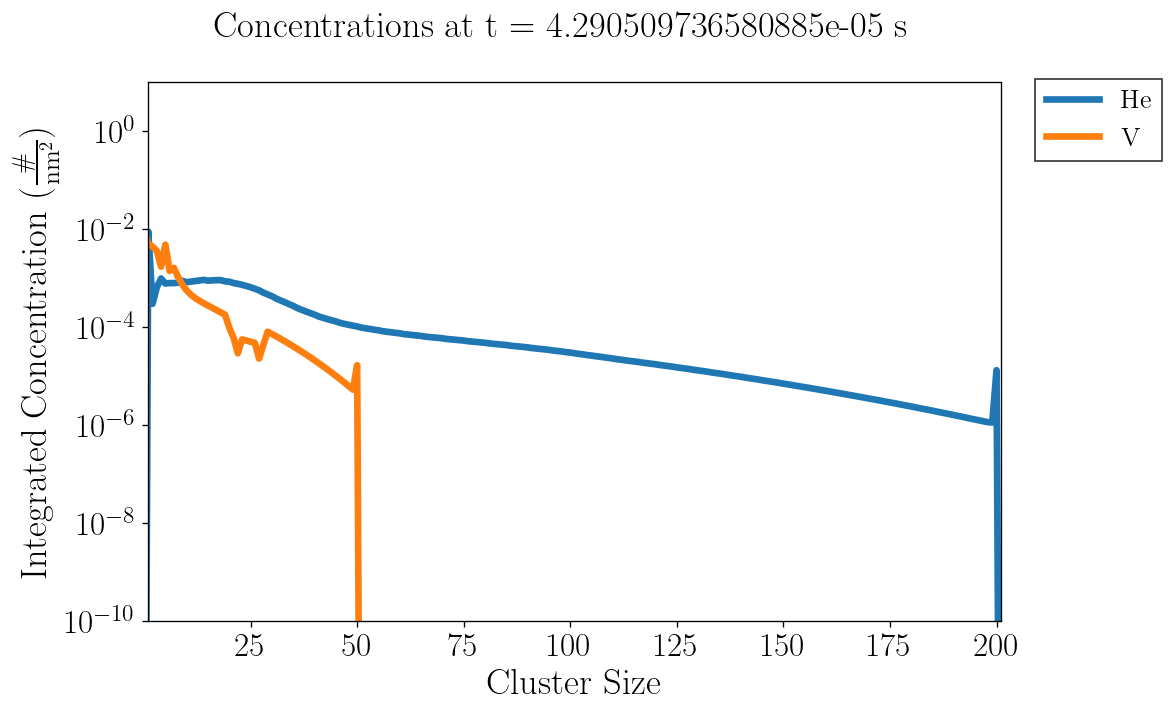

In [17]:
## Create plots
DPI, FIG_WIDTH, FIG_HEIGHT = 120, 1100, 700
fig, ax = plt.subplots(figsize=(FIG_WIDTH / DPI, FIG_HEIGHT / DPI), dpi=DPI)

## Optional plot settings if there is a LaTeX intstallation
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 16,
    "text.usetex": True
})

title = 'Concentrations at t = ' + str(time) + ' s'
fig.suptitle(title,fontsize=22)

## Plot the data
ax.plot(x, heArray, linewidth=4, label="He")
ax.plot(x, VArray, linewidth=4, label="V")
#ax.plot(x, dArray, linewidth=6, color="orange", label="D")
#ax.plot(x, tArray, linewidth=5, color="blue", label="T")
#ax.plot(x, hArray, linewidth=4, color="cyan", label="H = D+T")
ax.set_xlabel("Cluster Size",fontsize=22)
ax.set_ylabel(r"Integrated Concentration ($\frac{\#}{\mathrm{nm}^2}$)",fontsize=22)
ax.set_xlim([1, maxSize])
ax.set_ylim([1.0e-10, 10.0])
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)

## Plot the legend
ax.legend( bbox_to_anchor=(1.025, 1.03), loc="upper left", frameon=True, fancybox=False, shadow=False, edgecolor='black')

## Show the plots
plt.show()